# Reading Financial Statements

Explore a company's quarterly income statement to understand how revenue flows down to profit.

## Goals

- Load real quarterly data
- Calculate key profit metrics (Gross Profit, Operating Income, Net Income)
- Compute margin percentages at each level
- Visualize with a waterfall chart (how each dollar is spent)
- Show margin trends over multiple quarters

This is a hands-on way to build intuition for financial statement analysis using Python + pandas + matplotlib.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the income statement data
df = pd.read_csv('../data/income_statement.csv')
df

,quarter,revenue,cogs,research_and_development,sales_and_marketing,general_and_admin,interest_expense,tax_expense
0,Q1 2024,12500000,4375000,1875000,2500000,1250000,125000,475000
1,Q2 2024,13800000,4830000,2070000,2760000,1380000,125000,527000
2,Q3 2024,15200000,5472000,2280000,3040000,1520000,125000,553000
3,Q4 2024,17100000,6156000,2565000,3420000,1710000,125000,585000


In [2]:
# Calculate the key profit metrics
# Gross Profit = Revenue - Cost of Goods Sold (what's left after making the product)
df['gross_profit'] = df['revenue'] - df['cogs']

# Operating Income = Gross Profit - all operating expenses (what's left after running the business)
df['operating_income'] = df['gross_profit'] - df['research_and_development'] - df['sales_and_marketing'] - df['general_and_admin']

# Net Income = Operating Income - interest - taxes (what's actually left as profit)
df['net_income'] = df['operating_income'] - df['interest_expense'] - df['tax_expense']

df[['quarter', 'revenue', 'gross_profit', 'operating_income', 'net_income']]

,quarter,revenue,gross_profit,operating_income,net_income
0,Q1 2024,12500000,8125000,2500000,1900000
1,Q2 2024,13800000,8970000,2760000,2108000
2,Q3 2024,15200000,9728000,2888000,2210000
3,Q4 2024,17100000,10944000,3249000,2539000


In [3]:
# Calculate margin percentages - what % of each revenue dollar survives each tollbooth
df['gross_margin_pct'] = (df['gross_profit'] / df['revenue'] * 100).round(1)
df['operating_margin_pct'] = (df['operating_income'] / df['revenue'] * 100).round(1)
df['net_margin_pct'] = (df['net_income'] / df['revenue'] * 100).round(1)

df[['quarter', 'gross_margin_pct', 'operating_margin_pct', 'net_margin_pct']]

,quarter,gross_margin_pct,operating_margin_pct,net_margin_pct
0,Q1 2024,65.0,20.0,15.2
1,Q2 2024,65.0,20.0,15.3
2,Q3 2024,64.0,19.0,14.5
3,Q4 2024,64.0,19.0,14.8


## Waterfall Chart

A waterfall shows how each dollar of revenue is consumed by costs, ending at net profit.
Green bars are inflows (revenue and final net income). Red bars are outflows (expenses).


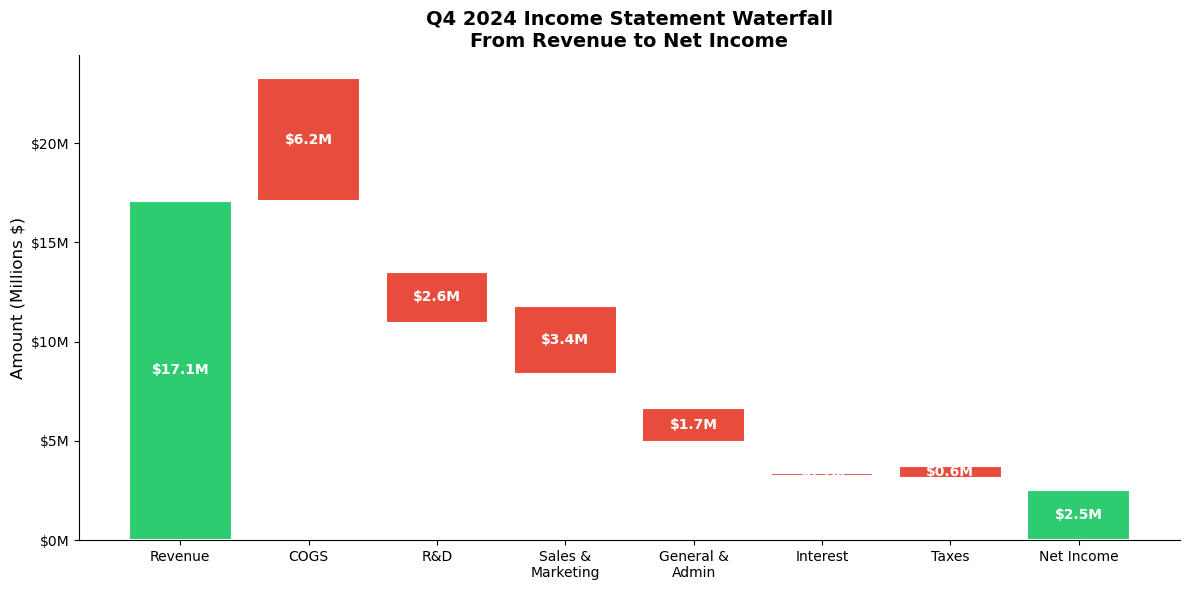

In [4]:
# Waterfall chart: How revenue flows down to net income (Q4 2024)
q4 = df[df['quarter'] == 'Q4 2024'].iloc[0]

categories = ['Revenue', 'COGS', 'R&D', 'Sales &\nMarketing', 'General &\nAdmin', 'Interest', 'Taxes', 'Net Income']
values = [
    q4['revenue'],
    -q4['cogs'],
    -q4['research_and_development'],
    -q4['sales_and_marketing'],
    -q4['general_and_admin'],
    -q4['interest_expense'],
    -q4['tax_expense'],
    q4['net_income']
]

# Calculate where each bar starts (running total)
running = [0]
for i in range(1, len(values) - 1):
    running.append(running[-1] + values[i-1])
running.append(0)  # Net income starts from zero

# Convert to millions for readability
values_m = [v / 1_000_000 for v in values]
running_m = [r / 1_000_000 for r in running]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if i == 0 or i == len(values)-1 else '#e74c3c' for i in range(len(values))]

ax.bar(categories, [abs(v) for v in values_m], bottom=running_m, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on each bar
for i, (val, bottom) in enumerate(zip(values_m, running_m)):
    label = f'${abs(val):.1f}M'
    y_pos = bottom + abs(val) / 2
    ax.text(i, y_pos, label, ha='center', va='center', fontweight='bold', fontsize=10, color='white')

ax.set_ylabel('Amount (Millions $)', fontsize=12)
ax.set_title('Q4 2024 Income Statement Waterfall\nFrom Revenue to Net Income', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}M'))

plt.tight_layout()
plt.savefig('../data/waterfall_chart.png', dpi=150, bbox_inches='tight')
plt.show()

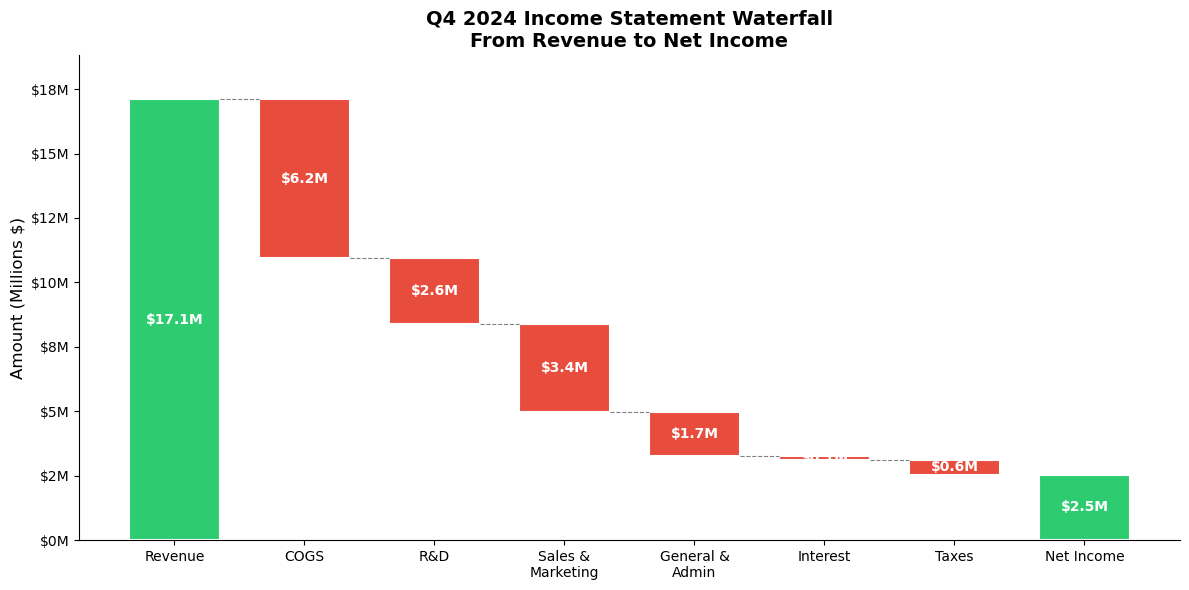

In [5]:
# Waterfall chart: How revenue flows down to net income (Q4 2024)
q4 = df[df['quarter'] == 'Q4 2024'].iloc[0]

categories = ['Revenue', 'COGS', 'R&D', 'Sales &\nMarketing', 'General &\nAdmin', 'Interest', 'Taxes', 'Net Income']
values = [
    q4['revenue'],
    -q4['cogs'],
    -q4['research_and_development'],
    -q4['sales_and_marketing'],
    -q4['general_and_admin'],
    -q4['interest_expense'],
    -q4['tax_expense'],
    q4['net_income']
]

# Calculate running totals properly
running_total = 0
bottoms = []
for i, val in enumerate(values):
    if i == 0:  # Revenue: starts from zero
        bottoms.append(0)
        running_total = val
    elif i == len(values) - 1:  # Net Income: starts from zero
        bottoms.append(0)
    else:  # Expenses: bar hangs DOWN from current running total
        running_total += val  # subtract the expense
        bottoms.append(running_total)  # bar bottom is the NEW total

# Convert to millions
values_m = [v / 1_000_000 for v in values]
bottoms_m = [b / 1_000_000 for b in bottoms]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if i == 0 or i == len(values)-1 else '#e74c3c' for i in range(len(values))]

bars = ax.bar(categories, [abs(v) for v in values_m], bottom=bottoms_m, 
              color=colors, edgecolor='white', linewidth=1.5, width=0.7)

# Add value labels on each bar
for i, (val, bottom) in enumerate(zip(values_m, bottoms_m)):
    label = f'${abs(val):.1f}M'
    y_pos = bottom + abs(val) / 2
    ax.text(i, y_pos, label, ha='center', va='center', fontweight='bold', fontsize=10, color='white')

# Add connector lines between bars
for i in range(len(values) - 2):
    if i == 0:
        connect_y = bottoms_m[1] + abs(values_m[1])
    else:
        connect_y = bottoms_m[i]
    ax.plot([i - 0.35 + 0.7, i + 1 - 0.35], [bottoms_m[i+1] + abs(values_m[i+1]), bottoms_m[i+1] + abs(values_m[i+1])], 
            color='gray', linewidth=0.8, linestyle='--')

ax.set_ylabel('Amount (Millions $)', fontsize=12)
ax.set_title('Q4 2024 Income Statement Waterfall\nFrom Revenue to Net Income', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}M'))
ax.set_ylim(0, max(values_m) * 1.1)

plt.tight_layout()
plt.savefig('../data/waterfall_chart.png', dpi=150, bbox_inches='tight')
plt.show()

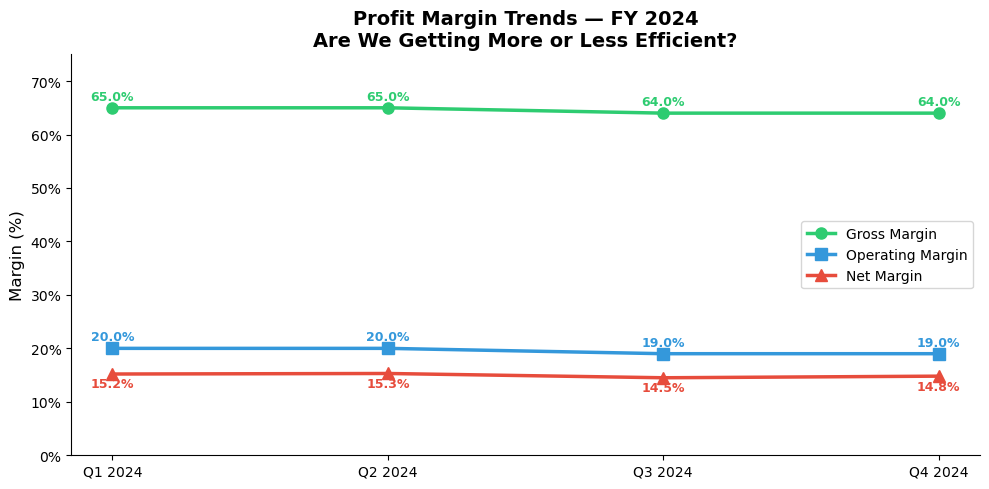

In [6]:
# Margin trends across all 4 quarters
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['quarter'], df['gross_margin_pct'], marker='o', linewidth=2.5, 
        color='#2ecc71', label='Gross Margin', markersize=8)
ax.plot(df['quarter'], df['operating_margin_pct'], marker='s', linewidth=2.5, 
        color='#3498db', label='Operating Margin', markersize=8)
ax.plot(df['quarter'], df['net_margin_pct'], marker='^', linewidth=2.5, 
        color='#e74c3c', label='Net Margin', markersize=8)

# Add value labels on each point
for col, color, offset in [('gross_margin_pct', '#2ecc71', 1.5), 
                            ('operating_margin_pct', '#3498db', 1.5), 
                            ('net_margin_pct', '#e74c3c', -2.5)]:
    for i, val in enumerate(df[col]):
        ax.text(i, val + offset, f'{val}%', ha='center', fontweight='bold', fontsize=9, color=color)

ax.set_ylabel('Margin (%)', fontsize=12)
ax.set_title('Profit Margin Trends — FY 2024\nAre We Getting More or Less Efficient?', fontsize=14, fontweight='bold')
ax.legend(loc='center right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 75)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../data/margin_trends.png', dpi=150, bbox_inches='tight')
plt.show()